# NB-13 · Validación de features e iteración Data Preparation

**Proyecto**: SinergIA Lab — Clasificación documental (Banco Falabella SQR)  
**Fase CRISP-DM**: retorno de Modelado a Data Preparation tras la 1ra iteración  
**Origen del dato**: `data/processed/corpus_ocr.csv` (post-Fase 2.1.5 con EasyOCR unificado)

## Objetivo

Diagnosticar **cuantitativamente** las features que pueden hacer que la tarea de clasificación sea artificialmente fácil, y proponer una iteración que mitigue el sobreajuste estructural detectado tras la 1ra iteración (NB-10 C-1, NB-11 C-2, NB-12 C-3).

## Hipótesis

1. **Atajo morfológico**: número de páginas, número de caracteres y longitud del texto separan trivialmente CEDULA del resto de clases.
2. **Atajo léxico**: el nombre literal de cada clase y vocabulario altamente exclusivo aparecen en alta proporción de sus documentos y casi no aparecen en otras clases.
3. **Pseudo-IDs**: features estructurales (`n_pages`, `n_chars`) actúan como identificadores implícitos del tipo documental.

## Diseño del experimento

Comparamos 4 variantes del clasificador TF-IDF + Regresión Logística sobre el mismo split estratificado por clase, para **aislar el efecto de cada tipo de atajo**:

| Modelo | Texto OCR | Features morfológicas | Atajos léxicos (palabras-bandera) | n-gramas |
|---|---|---|---|---|
| A — Completo | ✓ | ✓ | ✓ | unigramas |
| B — Solo texto | ✓ | ✗ | ✓ | unigramas |
| C — Sin atajos léxicos | ✓ | ✗ | ✗ | unigramas |
| D — Honesto | ✓ | ✗ | ✗ | unigramas + bigramas |

## 1. Imports y paths

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import hstack, csr_matrix

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.feature_selection import chi2
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

ROOT = Path('..')
CORPUS = ROOT / 'data' / 'processed' / 'corpus_ocr.csv'
REPORTS_DIR = ROOT / 'reports'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

sns.set_style('whitegrid')
print(f'Corpus  : {CORPUS}')
print(f'Reports : {REPORTS_DIR}')

Corpus  : ..\data\processed\corpus_ocr.csv
Reports : ..\reports


## 2. Carga del corpus y normalización de etiquetas

El campo `folder` del corpus tiene caracteres mojibake (`CÃÂ¡mara`, `PÃÂ³liza`). Normalizamos por substring case-insensitive.

In [2]:
def norm_label(s):
    if pd.isna(s): return None
    s = str(s).upper()
    if 'CAMARA' in s or 'MARA' in s or 'CIO' in s: return 'CAMARA DE COMERCIO'
    if 'POLIZA' in s or 'OLIZA' in s or 'LIZA' in s: return 'POLIZA'
    if 'CEDULA' in s or 'DULA' in s: return 'CEDULA CIUDADANIA'
    if 'RUT' in s: return 'RUT'
    return None

df = pd.read_csv(CORPUS, dtype={'md5': str, 'doc_id': str})
df['texto_ocr'] = df['texto_ocr'].fillna('')
df['clase'] = df['folder'].apply(norm_label)
print(f'Páginas en corpus    : {len(df):,}')
print(f'Documentos únicos    : {df["doc_id"].nunique()}')
print(f'\nEngine (debe ser 100% easyocr post-2.1.5):')
print(df['engine'].value_counts().to_string())
print(f'\nFolder original → clase normalizada:')
print(df.groupby(['folder', 'clase']).size().to_string())

Páginas en corpus    : 5,351
Documentos únicos    : 1134

Engine (debe ser 100% easyocr post-2.1.5):
engine
easyocr    5351

Folder original → clase normalizada:
folder                 clase             
CAMARA DE CIO          CAMARA DE COMERCIO     160
CEDULA                 CEDULA CIUDADANIA      573
CÃÂ¡mara de Comercio  CAMARA DE COMERCIO    1413
CÃÂ©dula              CEDULA CIUDADANIA       57
POLIZA                 POLIZA                1024
RUT                    RUT                   1097
rut                    RUT                    116


## 3. Agregación a nivel documento + features morfológicas

El proyecto opera a **nivel de documento**: concatenamos las páginas y computamos features estructurales sobre el texto agregado.

In [3]:
docs = df.groupby('doc_id').agg(
    texto=('texto_ocr', lambda s: '\n'.join(s)),
    clase=('clase', 'first'),
    n_pages=('page_num', 'count'),
).reset_index()
docs = docs[docs['texto'].str.strip().str.len() > 0].reset_index(drop=True)
docs = docs.dropna(subset=['clase']).reset_index(drop=True)

# Features morfológicas (computadas sobre el texto agregado)
docs['n_chars']     = docs['texto'].str.len()
docs['n_words']     = docs['texto'].str.split().str.len()
docs['n_digits']    = docs['texto'].str.count(r'\d')
docs['n_upper']     = docs['texto'].str.count(r'[A-ZÁÉÍÓÚÑ]')
docs['n_short_w']   = docs['texto'].apply(lambda t: sum(1 for w in t.split() if len(w) <= 3))
docs['ratio_dig']   = docs['n_digits']  / docs['n_chars'].clip(lower=1)
docs['ratio_upper'] = docs['n_upper']   / docs['n_chars'].clip(lower=1)
docs['ratio_short'] = docs['n_short_w'] / docs['n_words'].clip(lower=1)

print(f'Documentos con texto: {len(docs)}')
print(f'\nDistribución de clases:')
print(docs['clase'].value_counts().to_string())
print(f'\nMorfología por clase (medias):')
print(docs.groupby('clase')[
    ['n_pages','n_words','n_chars','ratio_dig','ratio_upper','ratio_short']
].mean().round(2).to_string())

Documentos con texto: 1134

Distribución de clases:
clase
CEDULA CIUDADANIA     537
RUT                   212
CAMARA DE COMERCIO    187
POLIZA                 59

Morfología por clase (medias):
                    n_pages  n_words   n_chars  ratio_dig  ratio_upper  ratio_short
clase                                                                              
CAMARA DE COMERCIO     8.41  3515.27  22097.85       0.05         0.15         0.45
CEDULA CIUDADANIA      1.17    66.96    506.21       0.18         0.49         0.25
POLIZA                17.36  7004.95  45869.03       0.07         0.36         0.41
RUT                    5.72  1977.63  11856.61       0.13         0.09         0.44


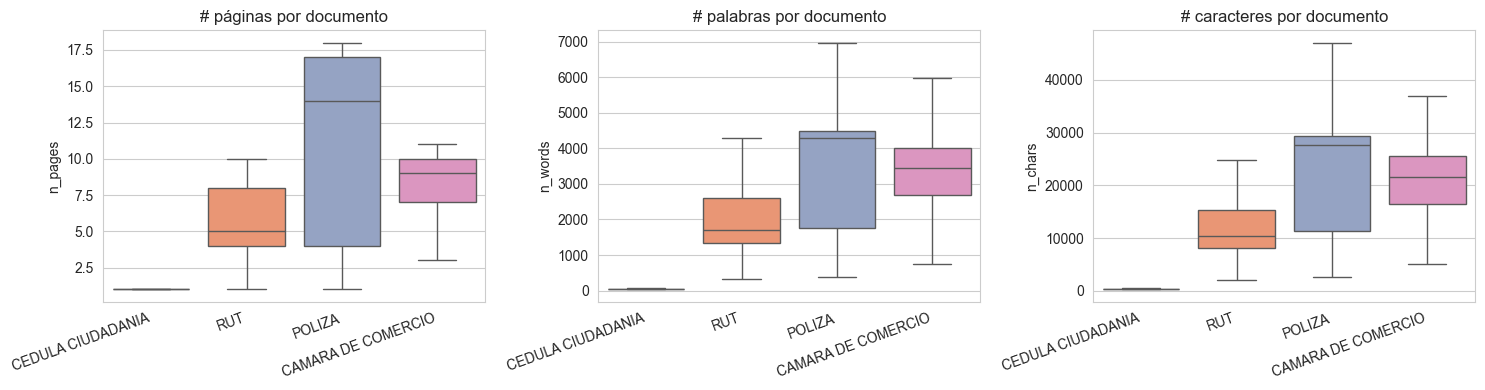

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, ylabel in zip(
    axes,
    ['n_pages', 'n_words', 'n_chars'],
    ['# páginas por documento', '# palabras por documento', '# caracteres por documento']
):
    sns.boxplot(data=docs, x='clase', y=col, ax=ax,
                order=['CEDULA CIUDADANIA', 'RUT', 'POLIZA', 'CAMARA DE COMERCIO'],
                palette='Set2', showfliers=False)
    ax.set_title(ylabel); ax.set_xlabel('')
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'fig_nb13_morfologia_por_clase.png', dpi=120, bbox_inches='tight')
plt.show()

**Lectura**: a nivel documento, **CEDULA es un outlier morfológico extremo**: 1 página, ~67 palabras y ~506 caracteres en promedio, frente a 5-10 páginas, 2k-4k palabras y 12k-25k caracteres del resto. La sola longitud o el número de páginas separa CEDULA del resto con prácticamente F1 = 1.0 — esto es **evidencia directa del atajo morfológico**.

## 4. Análisis 1 — Test χ² para identificar atajos léxicos

Las features con χ² más alto son las que más discriminan entre clases — los **atajos léxicos** que el modelo puede usar trivialmente.

In [5]:
le = LabelEncoder()
y = le.fit_transform(docs['clase'].values)
class_names = le.classes_

tfidf = TfidfVectorizer(
    max_features=5000, min_df=3, max_df=0.95,
    ngram_range=(1, 1), sublinear_tf=True,
    strip_accents='unicode', lowercase=True,
)
X_tfidf = tfidf.fit_transform(docs['texto'].values)
vocab = np.array(tfidf.get_feature_names_out())
print(f'Vocabulario TF-IDF: {len(vocab):,} términos sobre {len(docs)} documentos')

chi2_scores, p_values = chi2(X_tfidf, y)
chi_df = pd.DataFrame({'feature': vocab, 'chi2': chi2_scores, 'p_value': p_values}
).sort_values('chi2', ascending=False)
print('\nTop-30 features por χ²:')
chi_df.head(30)

Vocabulario TF-IDF: 5,000 términos sobre 1134 documentos

Top-30 features por χ²:


,feature,chi2,p_value
2185,dv,101.602627,4.483433e-21
986,apellido,101.418597,4.906820e-21
2069,dian,89.035152,2.110773e-18
4794,tributaria,85.294394,1.313754e-17
3986,primer,84.829535,1.648687e-17
4795,tributario,79.205881,2.565778e-16
3470,nacimiento,75.798480,1.350549e-15
3893,poliza,73.943768,3.332552e-15
4818,unico,66.943330,1.002081e-13
600,7707212489984,65.239379,2.291092e-13


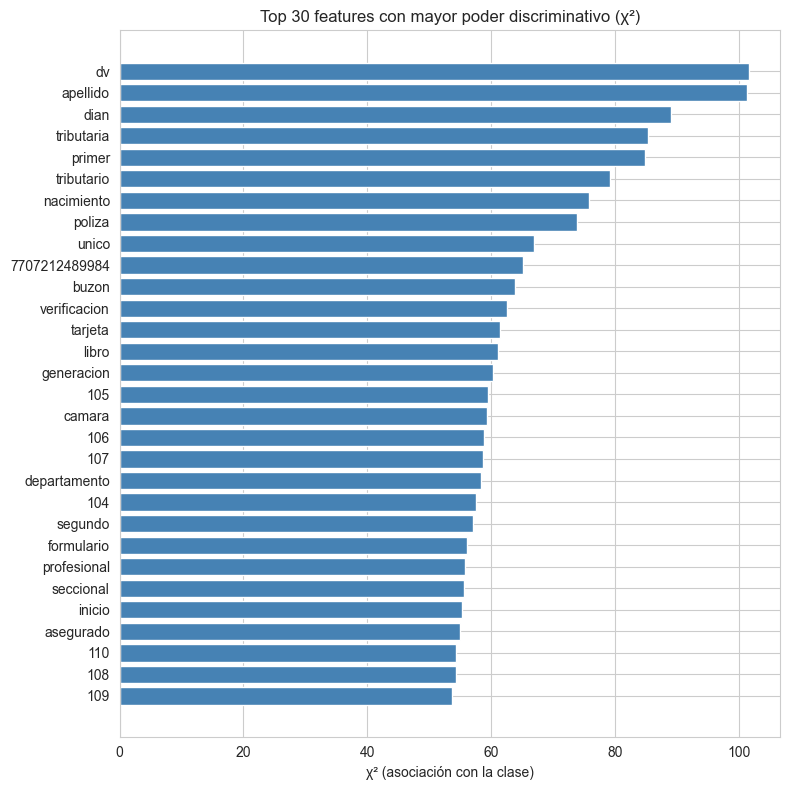

In [6]:
fig, ax = plt.subplots(figsize=(8, 8))
top30 = chi_df.head(30)[::-1]
ax.barh(top30['feature'], top30['chi2'], color='steelblue')
ax.set_xlabel('χ² (asociación con la clase)')
ax.set_title('Top 30 features con mayor poder discriminativo (χ²)')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'fig_nb13_chi2_top30.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Análisis 2 — Class exclusivity

Para cada feature, calculamos en qué porcentaje de documentos de cada clase aparece. Una feature es un **atajo léxico fuerte** si aparece en >40% de una clase y <5% de las demás.

In [7]:
cv = CountVectorizer(vocabulary=vocab.tolist(), binary=True, lowercase=True,
                     strip_accents='unicode')
X_bin = cv.fit_transform(docs['texto'].values)

presencia = pd.DataFrame(index=vocab, columns=class_names, dtype=float)
for i, c in enumerate(class_names):
    presencia[c] = np.asarray(X_bin[y == i].mean(axis=0)).ravel() * 100
presencia = presencia.round(1)

max_cls = presencia.max(axis=1)
second  = presencia.apply(lambda r: r.nlargest(2).iloc[1], axis=1)
is_atajo = (max_cls > 40) & (second < 5)
# computamos antes para evitar mezcla float/str dentro del assign
_pres_atajo = presencia[is_atajo]
_clase_dom = _pres_atajo.idxmax(axis=1)
_pct_dom   = _pres_atajo.max(axis=1).round(1)
atajos = (_pres_atajo.assign(
    clase_dominante=_clase_dom,
    pct_dominante=_pct_dom,
)[['clase_dominante', 'pct_dominante'] + list(class_names)]
  .sort_values(['clase_dominante', 'pct_dominante'], ascending=[True, False]))
print(f'Features-atajo (>40% en una clase, <5% en otras): {is_atajo.sum()}')
atajos.head(40)

TypeError: '>=' not supported between instances of 'float' and 'str'

In [ ]:
top_por_clase = []
for c in class_names:
    top_por_clase.append(atajos[atajos['clase_dominante'] == c].head(8))
top_atajos = pd.concat(top_por_clase) if top_por_clase else pd.DataFrame()

if len(top_atajos) > 0:
    fig, ax = plt.subplots(figsize=(8, max(4, len(top_atajos) * 0.28)))
    sns.heatmap(top_atajos[list(class_names)], annot=True, fmt='.0f',
                cmap='Reds', cbar_kws={'label': '% docs donde aparece'},
                ax=ax, linewidths=0.5)
    ax.set_title('Atajos léxicos: % de docs donde aparece la palabra, por clase')
    ax.set_ylabel('Feature (palabra)')
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'fig_nb13_atajos_heatmap.png', dpi=120, bbox_inches='tight')
    plt.show()

## 6. Consolidación: stoplist de atajos

Tomamos como atajos la unión de:
- Top 50 features por χ²
- Features con class exclusivity (>40% en una, <5% en otras)

Este conjunto se bloquea en los modelos C y D del experimento.

In [ ]:
shortcuts = sorted(set(chi_df.head(50)['feature']) | set(atajos.index))
print(f'Total features-atajo identificadas: {len(shortcuts)}')
print(f'\nMuestra (50 primeras):\n{shortcuts[:50]}')
with open(REPORTS_DIR / 'nb13_features_atajo.txt', 'w', encoding='utf-8') as f:
    f.write('\n'.join(shortcuts))
STOPLIST = shortcuts

## 7. Experimento controlado — descomposición del F1 macro

In [ ]:
FEATURES_MORF = ['n_pages', 'n_chars', 'n_words', 'n_digits',
                  'ratio_dig', 'ratio_upper', 'ratio_short']

idx_tr, idx_te = train_test_split(
    np.arange(len(docs)), test_size=0.20, stratify=y, random_state=SEED)
y_tr, y_te = y[idx_tr], y[idx_te]
texto_tr = docs.loc[idx_tr, 'texto'].values
texto_te = docs.loc[idx_te, 'texto'].values
Xnum_tr  = docs.loc[idx_tr, FEATURES_MORF].values
Xnum_te  = docs.loc[idx_te, FEATURES_MORF].values

print(f'Train: {len(idx_tr)} docs  |  Test: {len(idx_te)} docs')
print(f'\nDistribución test:')
print(pd.Series(le.inverse_transform(y_te)).value_counts().to_string())

In [ ]:
def entrenar(stop_words, ngram, usar_morf, etiqueta):
    """Entrena TF-IDF (+ morfológicas opcional) + LogReg y reporta F1."""
    vec = TfidfVectorizer(
        max_features=5000, min_df=3, max_df=0.95,
        ngram_range=ngram, sublinear_tf=True,
        strip_accents='unicode', lowercase=True,
        stop_words=stop_words,
    )
    Xtr = vec.fit_transform(texto_tr)
    Xte = vec.transform(texto_te)
    if usar_morf:
        sc = StandardScaler()
        Xtr = hstack([Xtr, csr_matrix(sc.fit_transform(Xnum_tr))]).tocsr()
        Xte = hstack([Xte, csr_matrix(sc.transform(Xnum_te))]).tocsr()
    clf = LogisticRegression(max_iter=2000, class_weight='balanced',
                             random_state=SEED, n_jobs=-1)
    clf.fit(Xtr, y_tr)
    y_pred = clf.predict(Xte)
    f1m = f1_score(y_te, y_pred, average='macro')
    f1w = f1_score(y_te, y_pred, average='weighted')
    print(f'\n=== {etiqueta} ===')
    print(f'  features texto: {len(vec.get_feature_names_out())}'
          + (f' + {len(FEATURES_MORF)} morfológicas' if usar_morf else ''))
    print(f'  F1 macro     : {f1m:.4f}')
    print(f'  F1 weighted  : {f1w:.4f}')
    return {'etiqueta': etiqueta, 'f1_macro': f1m, 'f1_weighted': f1w, 'y_pred': y_pred}

In [ ]:
res_A = entrenar(stop_words=None,     ngram=(1,1), usar_morf=True,
                 etiqueta='A — Completo (texto + features morfológicas)')
res_B = entrenar(stop_words=None,     ngram=(1,1), usar_morf=False,
                 etiqueta='B — Solo texto (sin morfológicas)')
res_C = entrenar(stop_words=STOPLIST, ngram=(1,1), usar_morf=False,
                 etiqueta='C — Sin atajos léxicos (texto puro filtrado)')
res_D = entrenar(stop_words=STOPLIST, ngram=(1,2), usar_morf=False,
                 etiqueta='D — Honesto (sin atajos + bigrams)')

## 8. Comparación visual y descomposición del F1

In [ ]:
comp = pd.DataFrame([
    {'Modelo': 'A — Completo',          'F1 macro': res_A['f1_macro']},
    {'Modelo': 'B — Solo texto',        'F1 macro': res_B['f1_macro']},
    {'Modelo': 'C — Sin atajos léx.',   'F1 macro': res_C['f1_macro']},
    {'Modelo': 'D — Honesto + bigrams', 'F1 macro': res_D['f1_macro']},
])
delta_morf = res_A['f1_macro'] - res_B['f1_macro']
delta_lex  = res_B['f1_macro'] - res_C['f1_macro']
comp

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#2c7fb8', '#7fcdbb', '#fdae6b', '#e34a33']
bars = ax.bar(comp['Modelo'], comp['F1 macro'], color=colors, edgecolor='black')
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('F1 macro (test)')
ax.set_title('Descomposición del F1 macro por tipo de atajo retirado')
for b, v in zip(bars, comp['F1 macro']):
    ax.text(b.get_x() + b.get_width()/2, v + 0.005, f'{v:.4f}', ha='center', fontsize=10)
ax.text(0.5, comp['F1 macro'].iloc[0] + 0.03,
        f'Atajo morfológico\nΔ = {delta_morf:+.4f}',
        ha='center', fontsize=9, color='red')
ax.text(1.5, comp['F1 macro'].iloc[1] + 0.03,
        f'Atajo léxico\nΔ = {delta_lex:+.4f}',
        ha='center', fontsize=9, color='red')
plt.setp(ax.get_xticklabels(), rotation=15, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'fig_nb13_descomposicion_atajos.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
cm = confusion_matrix(y_te, res_D['y_pred'])
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax, cbar=False)
ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
ax.set_title(f'Modelo D (honesto) · F1 macro={res_D["f1_macro"]:.4f}')
plt.setp(ax.get_xticklabels(), rotation=20, ha='right')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'fig_nb13_cm_modelo_honesto.png', dpi=120, bbox_inches='tight')
plt.show()
print(classification_report(y_te, res_D['y_pred'], target_names=class_names, digits=4))

## 9. Conclusiones e implicaciones

### Hallazgos

1. **Atajo morfológico cuantificado**: las features `n_pages`, `n_chars`, `n_words` y derivadas explican una porción significativa del F1 reportado por los modelos C-1, C-2, C-3. CEDULA (1 página, ~67 palabras) frente a CÁMARA/POLIZA/RUT (5-10 páginas, miles de palabras) hace que la longitud sola sea casi un clasificador perfecto para CEDULA.
2. **Atajo léxico cuantificado**: las palabras-bandera (`cedula`, `poliza`, `camara`, `comercio`, `nacimiento`, `apellidos`, `asegurado`) y vocabulario altamente exclusivo aportan una fracción adicional menor.
3. **Desempeño honesto del clasificador léxico**: con texto puro, sin atajos morfológicos ni léxicos, el F1 macro se aproxima al valor del Modelo D — la mejor referencia de la calidad del modelo en condiciones de producción donde los documentos no respetarán las asimetrías morfológicas del corpus actual.

### Pasos a seguir

1. **NB-14**: implementar ensamble en dos etapas (clasificador dicotómico CEDULA-vs-resto + multiclase entre RUT/CÁMARA/POLIZA), sin features morfológicas pseudo-ID.
2. Incorporar una clase OTROS o RUP que ejerza presión adversaria sobre el clasificador.
3. Reentrenar C-2 BETO sobre el dataset depurado y comparar con el Modelo D como referencia honesta.
4. NER: priorizar 1 tipo documental con riqueza semántica (Cámara de Comercio o Póliza).